## Data Preprocessing

In [1]:
import matplotlib.pyplot as plt

%matplotlib inline
import os
import numpy as np
import sentencepiece as spm
import scienceplots
import pandas as pd
from rdkit import Chem
import torch, random

plt.rcParams.update({"text.usetex": True, "font.size": 14})
plt.style.use(["science", "no-latex"])
seed = 42
torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)
np.random.seed(seed)
random.seed(seed)

## Model Performance

Avg Validity 0.7097 152 Maximum: 0.7152 Std: 0.0038
Max Validity 0.7152 152 Average: 0.7097 Std: 0.0038
Avg Overall Validity 0.1779 167 Maximum: 0.1815 Std: 0.0036
Max Overall Validity 0.1815 167 Average: 0.1779 Std: 0.0036
Min Validation Loss at Epoch 198 Min Loss: 0.583 Final Val Loss: 0.5832


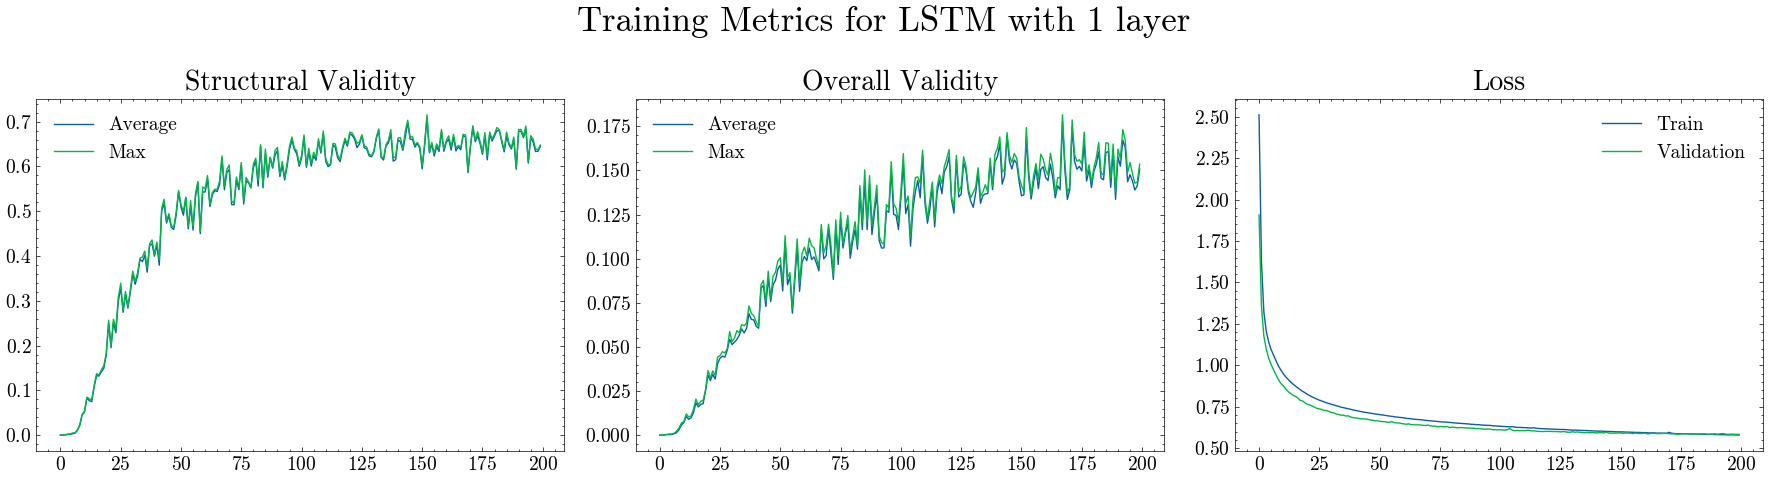

In [11]:
import re
import matplotlib.pyplot as plt
import numpy as np

logv2 = "Liu_Kheyer_Retrosynthesis_Data/reproduced/v2/train.log"
logv2_str = open(logv2, "r").read()

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Structural Validity
patt = re.compile(r"- Validity\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})")
vals = patt.findall(logv2_str)
avg_vals = [float(val[0]) for val in vals]
max_vals = [float(val[3]) for val in vals]
std_vals = [float(val[1]) for val in vals]
axs[0].plot(avg_vals, label="Average")
axs[0].plot(max_vals, label="Max")
axs[0].set_title("Structural Validity",fontsize=20)
axs[0].legend()
print("Avg Validity", np.max(avg_vals), np.argmax(avg_vals),
      "Maximum:", max_vals[np.argmax(avg_vals)],
      "Std:", std_vals[np.argmax(avg_vals)])
print("Max Validity", np.max(max_vals), np.argmax(max_vals),
      "Average:", avg_vals[np.argmax(max_vals)],
      "Std:", std_vals[np.argmax(max_vals)])

# Overall Validity
patt = re.compile(r"- Overall Validity\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})")
vals = patt.findall(logv2_str)
avg_vals = [float(val[0]) for val in vals]
max_vals = [float(val[3]) for val in vals]
std_vals = [float(val[1]) for val in vals]
axs[1].plot(avg_vals, label="Average")
axs[1].plot(max_vals, label="Max")
axs[1].set_title("Overall Validity", fontsize=20)
axs[1].legend()
print("Avg Overall Validity", np.max(avg_vals), np.argmax(avg_vals),
      "Maximum:", max_vals[np.argmax(avg_vals)],
      "Std:", std_vals[np.argmax(avg_vals)])
print("Max Overall Validity", np.max(max_vals), np.argmax(max_vals),
      "Average:", avg_vals[np.argmax(max_vals)],
      "Std:", std_vals[np.argmax(max_vals)])

# Loss Plot
patt_val = re.compile(r"val loss:\s+(\d\.\d{4})")
patt_train = re.compile(r"Train Loss:\s+(\d\.\d{5})")
val_losses = [float(x) for x in patt_val.findall(logv2_str)]
train_losses = [float(x) for x in patt_train.findall(logv2_str)]
axs[2].plot(train_losses, label="Train")
axs[2].plot(val_losses, label="Validation")
axs[2].set_title("Loss", fontsize=20)
axs[2].legend()
print("Min Validation Loss at Epoch", np.argmin(val_losses),
      "Min Loss:", np.min(val_losses),
      "Final Val Loss:", val_losses[-1])

fig.suptitle("Training Metrics for LSTM with 1 layer", fontsize=25)
plt.tight_layout()
plt.savefig("results/LSTM1_layer_model_evaluation_metrics.png", dpi=300)
plt.show()

Avg Validity 0.7511 185 Maximum: 0.7579 Std: 0.0047
Max Validity 0.7579 185 Average: 0.7511 Std: 0.0047
Avg Overall Validity 0.3143 191 Maximum: 0.3217 Std: 0.0039
Max Overall Validity 0.3217 191 Average: 0.3143 Std: 0.0039
Min Validation Loss at Epoch 189 Min Loss: 0.5105 Final Val Loss: 0.5115


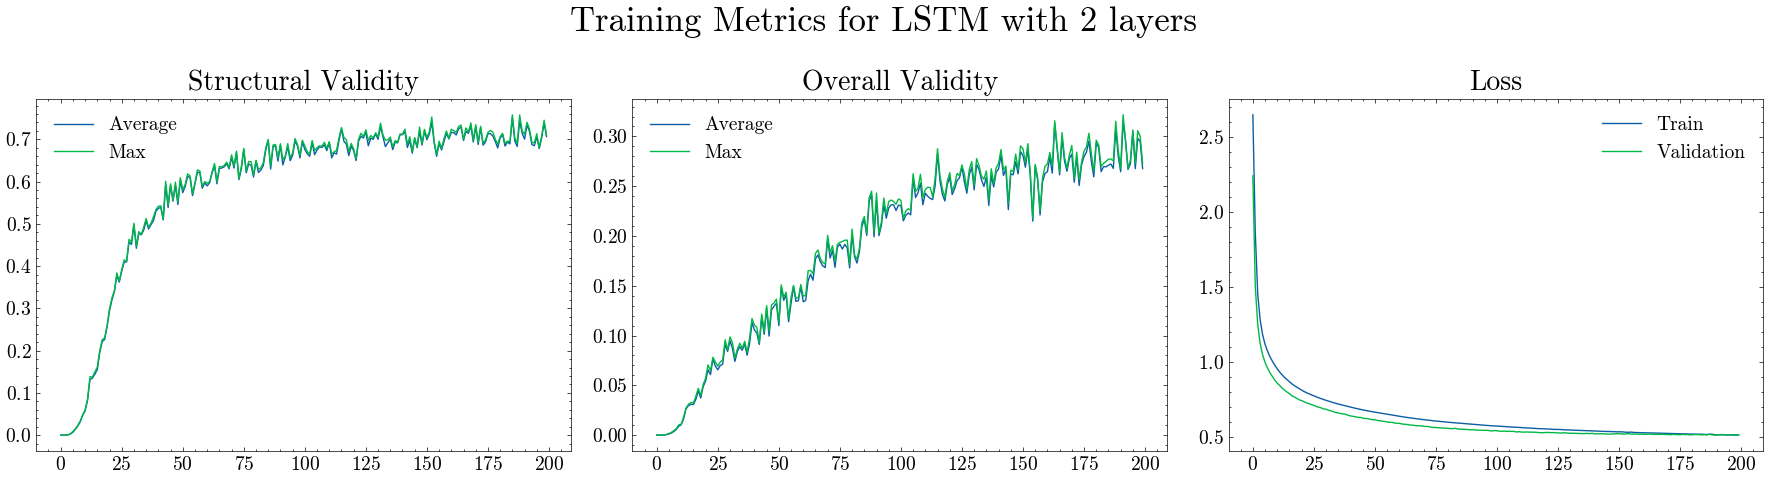

In [13]:
import re
import matplotlib.pyplot as plt
import numpy as np

logv2 = "Liu_Kheyer_Retrosynthesis_Data/reproduced/v2.2/train.log"
logv2_str = open(logv2, "r").read()

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Structural Validity
patt = re.compile(r"- Validity\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})")
vals = patt.findall(logv2_str)
avg_vals = [float(val[0]) for val in vals]
max_vals = [float(val[3]) for val in vals]
std_vals = [float(val[1]) for val in vals]
axs[0].plot(avg_vals, label="Average")
axs[0].plot(max_vals, label="Max")
axs[0].set_title("Structural Validity",fontsize=20)
axs[0].legend()
print("Avg Validity", np.max(avg_vals), np.argmax(avg_vals),
      "Maximum:", max_vals[np.argmax(avg_vals)],
      "Std:", std_vals[np.argmax(avg_vals)])
print("Max Validity", np.max(max_vals), np.argmax(max_vals),
      "Average:", avg_vals[np.argmax(max_vals)],
      "Std:", std_vals[np.argmax(max_vals)])

# Overall Validity
patt = re.compile(r"- Overall Validity\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})")
vals = patt.findall(logv2_str)
avg_vals = [float(val[0]) for val in vals]
max_vals = [float(val[3]) for val in vals]
std_vals = [float(val[1]) for val in vals]
axs[1].plot(avg_vals, label="Average")
axs[1].plot(max_vals, label="Max")
axs[1].set_title("Overall Validity", fontsize=20)
axs[1].legend()
print("Avg Overall Validity", np.max(avg_vals), np.argmax(avg_vals),
      "Maximum:", max_vals[np.argmax(avg_vals)],
      "Std:", std_vals[np.argmax(avg_vals)])
print("Max Overall Validity", np.max(max_vals), np.argmax(max_vals),
      "Average:", avg_vals[np.argmax(max_vals)],
      "Std:", std_vals[np.argmax(max_vals)])

# Loss Plot
patt_val = re.compile(r"val loss:\s+(\d\.\d{4})")
patt_train = re.compile(r"Train Loss:\s+(\d\.\d{5})")
val_losses = [float(x) for x in patt_val.findall(logv2_str)]
train_losses = [float(x) for x in patt_train.findall(logv2_str)]
axs[2].plot(train_losses, label="Train")
axs[2].plot(val_losses, label="Validation")
axs[2].set_title("Loss", fontsize=20)
axs[2].legend()
print("Min Validation Loss at Epoch", np.argmin(val_losses),
      "Min Loss:", np.min(val_losses),
      "Final Val Loss:", val_losses[-1])

fig.suptitle("Training Metrics for LSTM with 2 layers", fontsize=25)
plt.tight_layout()
plt.savefig("results/LSTM2_layer_model_evaluation_metrics.png", dpi=300)
plt.show()

Avg Validity 0.8158 139 Maximum: 0.8219 Std: 0.0039
Max Validity 0.8219 139 Average: 0.8158 Std: 0.0039
Avg Overall Validity 0.3652 194 Maximum: 0.37 Std: 0.0041
Max Overall Validity 0.37 194 Average: 0.3652 Std: 0.0041
Min Validation Loss at Epoch 186 Min Loss: 0.4813 Final Val Loss: 0.4817


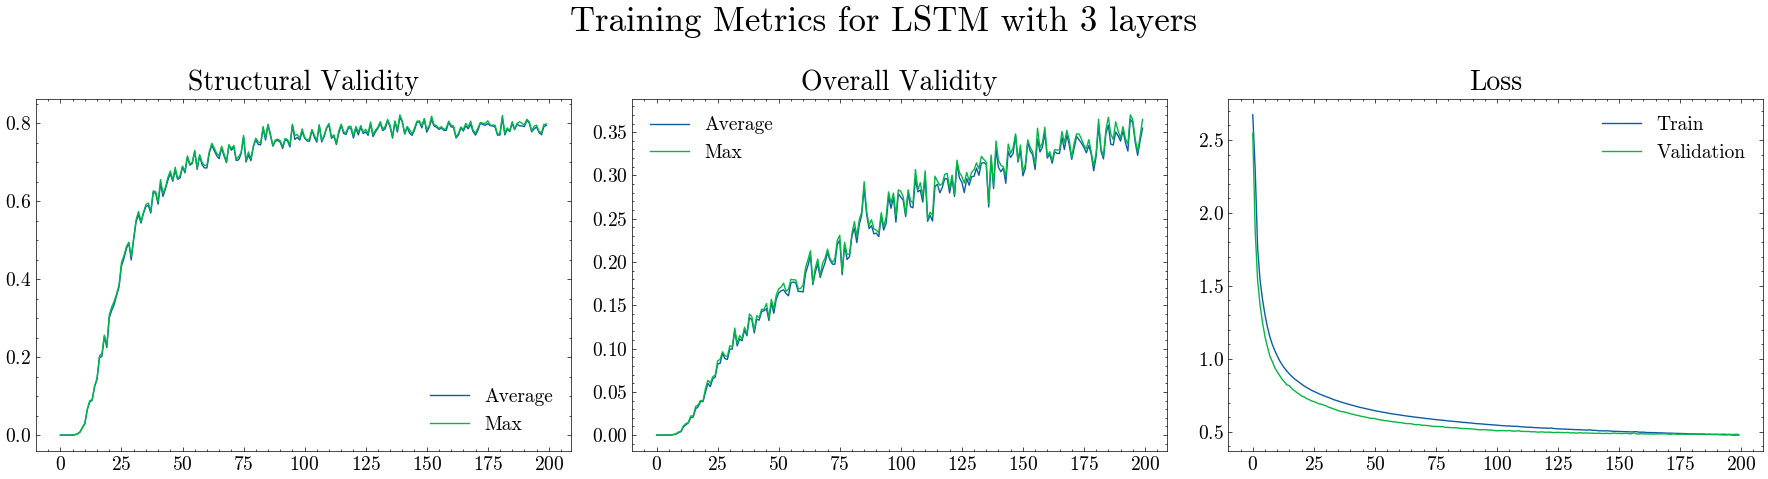

In [14]:
import re
import matplotlib.pyplot as plt
import numpy as np

logv2 = "Liu_Kheyer_Retrosynthesis_Data/reproduced/v2.3/train.log"
logv2_str = open(logv2, "r").read()

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Structural Validity
patt = re.compile(r"- Validity\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})")
vals = patt.findall(logv2_str)
avg_vals = [float(val[0]) for val in vals]
max_vals = [float(val[3]) for val in vals]
std_vals = [float(val[1]) for val in vals]
axs[0].plot(avg_vals, label="Average")
axs[0].plot(max_vals, label="Max")
axs[0].set_title("Structural Validity",fontsize=20)
axs[0].legend()
print("Avg Validity", np.max(avg_vals), np.argmax(avg_vals),
      "Maximum:", max_vals[np.argmax(avg_vals)],
      "Std:", std_vals[np.argmax(avg_vals)])
print("Max Validity", np.max(max_vals), np.argmax(max_vals),
      "Average:", avg_vals[np.argmax(max_vals)],
      "Std:", std_vals[np.argmax(max_vals)])

# Overall Validity
patt = re.compile(r"- Overall Validity\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})")
vals = patt.findall(logv2_str)
avg_vals = [float(val[0]) for val in vals]
max_vals = [float(val[3]) for val in vals]
std_vals = [float(val[1]) for val in vals]
axs[1].plot(avg_vals, label="Average")
axs[1].plot(max_vals, label="Max")
axs[1].set_title("Overall Validity", fontsize=20)
axs[1].legend()
print("Avg Overall Validity", np.max(avg_vals), np.argmax(avg_vals),
      "Maximum:", max_vals[np.argmax(avg_vals)],
      "Std:", std_vals[np.argmax(avg_vals)])
print("Max Overall Validity", np.max(max_vals), np.argmax(max_vals),
      "Average:", avg_vals[np.argmax(max_vals)],
      "Std:", std_vals[np.argmax(max_vals)])

# Loss Plot
patt_val = re.compile(r"val loss:\s+(\d\.\d{4})")
patt_train = re.compile(r"Train Loss:\s+(\d\.\d{5})")
val_losses = [float(x) for x in patt_val.findall(logv2_str)]
train_losses = [float(x) for x in patt_train.findall(logv2_str)]
axs[2].plot(train_losses, label="Train")
axs[2].plot(val_losses, label="Validation")
axs[2].set_title("Loss", fontsize=20)
axs[2].legend()
print("Min Validation Loss at Epoch", np.argmin(val_losses),
      "Min Loss:", np.min(val_losses),
      "Final Val Loss:", val_losses[-1])

fig.suptitle("Training Metrics for LSTM with 3 layers", fontsize=25)
plt.tight_layout()
plt.savefig("results/LSTM3_layer_model_evaluation_metrics.png", dpi=300)
plt.show()

Avg Validity 0.8077 176 Maximum: 0.8146 Std: 0.0047
Max Validity 0.8146 176 Average: 0.8077 Std: 0.0047
Avg Overall Validity 0.2592 167 Maximum: 0.2661 Std: 0.0052
Max Overall Validity 0.2661 167 Average: 0.2592 Std: 0.0052
Min Validation Loss at Epoch 175 Min Loss: 0.5034 Final Val Loss: 0.5047


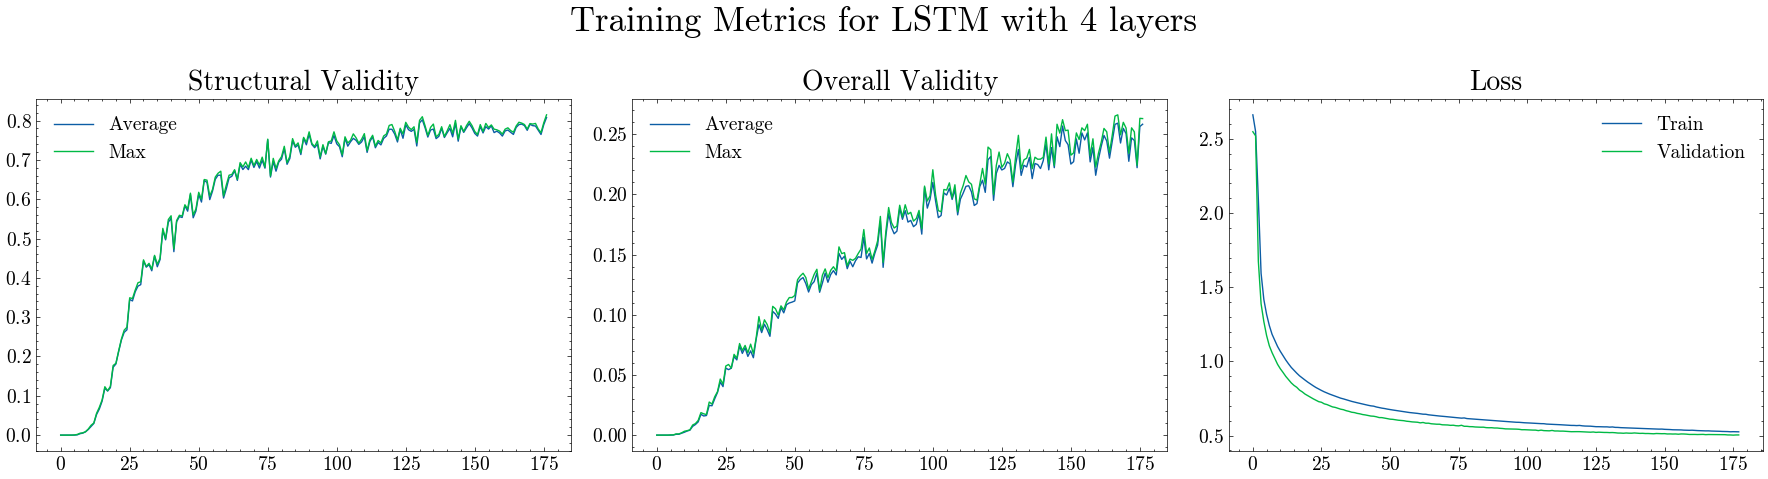

In [15]:
import re
import matplotlib.pyplot as plt
import numpy as np

logv2 = "Liu_Kheyer_Retrosynthesis_Data/reproduced/v2.4/train.log"
logv2_str = open(logv2, "r").read()

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Structural Validity
patt = re.compile(r"- Validity\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})")
vals = patt.findall(logv2_str)
avg_vals = [float(val[0]) for val in vals]
max_vals = [float(val[3]) for val in vals]
std_vals = [float(val[1]) for val in vals]
axs[0].plot(avg_vals, label="Average")
axs[0].plot(max_vals, label="Max")
axs[0].set_title("Structural Validity",fontsize=20)
axs[0].legend()
print("Avg Validity", np.max(avg_vals), np.argmax(avg_vals),
      "Maximum:", max_vals[np.argmax(avg_vals)],
      "Std:", std_vals[np.argmax(avg_vals)])
print("Max Validity", np.max(max_vals), np.argmax(max_vals),
      "Average:", avg_vals[np.argmax(max_vals)],
      "Std:", std_vals[np.argmax(max_vals)])

# Overall Validity
patt = re.compile(r"- Overall Validity\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})")
vals = patt.findall(logv2_str)
avg_vals = [float(val[0]) for val in vals]
max_vals = [float(val[3]) for val in vals]
std_vals = [float(val[1]) for val in vals]
axs[1].plot(avg_vals, label="Average")
axs[1].plot(max_vals, label="Max")
axs[1].set_title("Overall Validity", fontsize=20)
axs[1].legend()
print("Avg Overall Validity", np.max(avg_vals), np.argmax(avg_vals),
      "Maximum:", max_vals[np.argmax(avg_vals)],
      "Std:", std_vals[np.argmax(avg_vals)])
print("Max Overall Validity", np.max(max_vals), np.argmax(max_vals),
      "Average:", avg_vals[np.argmax(max_vals)],
      "Std:", std_vals[np.argmax(max_vals)])

# Loss Plot
patt_val = re.compile(r"val loss:\s+(\d\.\d{4})")
patt_train = re.compile(r"Train Loss:\s+(\d\.\d{5})")
val_losses = [float(x) for x in patt_val.findall(logv2_str)]
train_losses = [float(x) for x in patt_train.findall(logv2_str)]
axs[2].plot(train_losses, label="Train")
axs[2].plot(val_losses, label="Validation")
axs[2].set_title("Loss", fontsize=20)
axs[2].legend()
print("Min Validation Loss at Epoch", np.argmin(val_losses),
      "Min Loss:", np.min(val_losses),
      "Final Val Loss:", val_losses[-1])

fig.suptitle("Training Metrics for LSTM with 4 layers", fontsize=25)
plt.tight_layout()
plt.savefig("results/LSTM4_layer_model_evaluation_metrics.png", dpi=300)
plt.show()

Avg Structural Validity 0.8811 119 Maximum: 0.8829 Std: 0.0011
Max Structural Validity 0.8848 117 Average: 0.8799 Std: 0.0026
Avg Overall Validity 0.3358 111 Maximum: 0.3387 Std: 0.0015
Max Overall Validity 0.3392 115 Average: 0.3293 Std: 0.0052
Min Validation Loss at Epoch 84 Min Loss: 49.5652 Final Val Loss: 50.5195


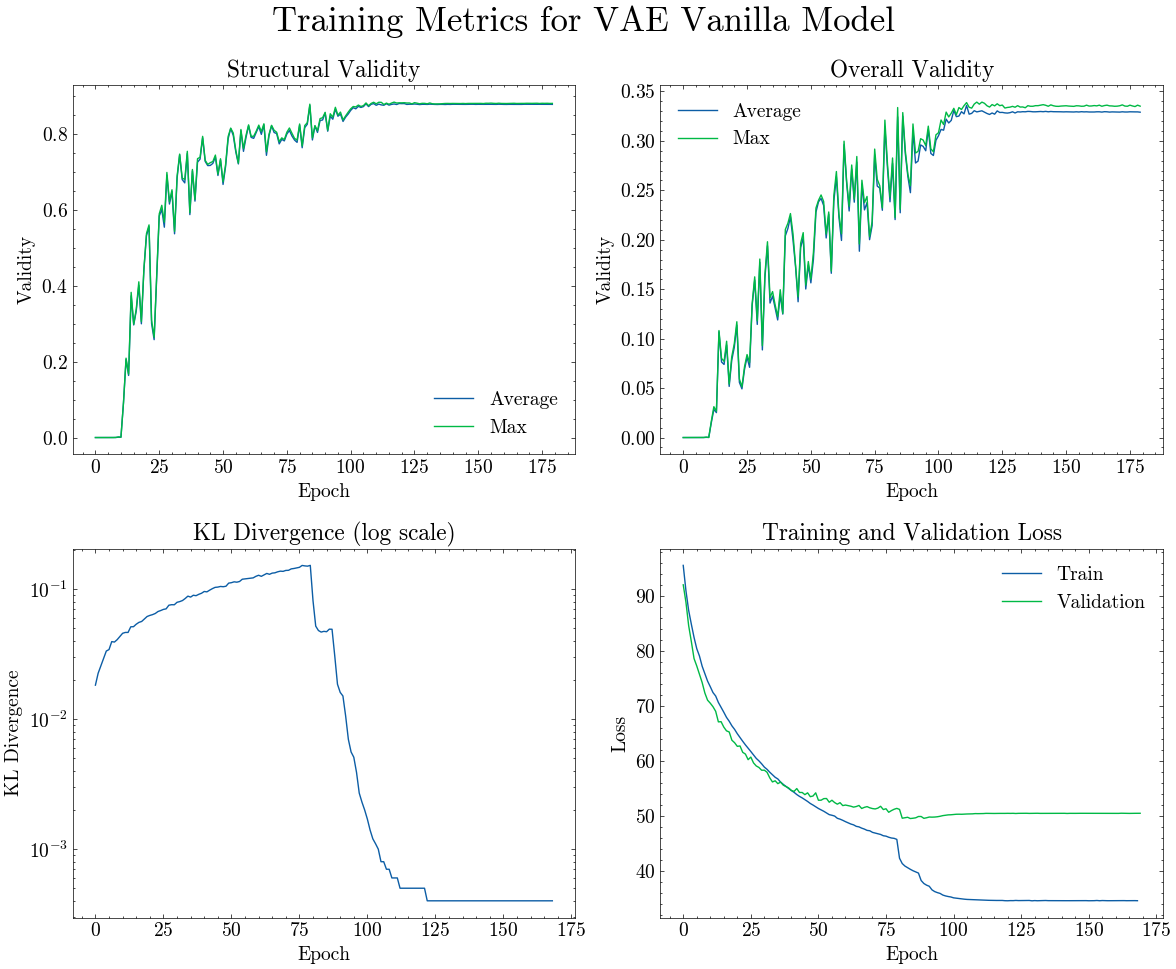

In [20]:
import re
import matplotlib.pyplot as plt
import numpy as np

logv2 = "Liu_Kheyer_Retrosynthesis_Data/reproduced/v4/train.log"
logv2_str = open(logv2, "r").read()

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

# Structural Validity
patt = re.compile(r"- Validity\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})")
vals = patt.findall(logv2_str)
avg_vals = [float(val[0]) for val in vals]
max_vals = [float(val[3]) for val in vals]
std_vals = [float(val[1]) for val in vals]
axs[0].plot(avg_vals, label="Average")
axs[0].plot(max_vals, label="Max")
axs[0].set_title("Structural Validity")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Validity")
axs[0].legend()
print("Avg Structural Validity", np.max(avg_vals), np.argmax(avg_vals),
      "Maximum:", max_vals[np.argmax(avg_vals)],
      "Std:", std_vals[np.argmax(avg_vals)])
print("Max Structural Validity", np.max(max_vals), np.argmax(max_vals),
      "Average:", avg_vals[np.argmax(max_vals)],
      "Std:", std_vals[np.argmax(max_vals)])

# Overall Validity
patt = re.compile(r"- Overall Validity\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})")
vals = patt.findall(logv2_str)
avg_vals = [float(val[0]) for val in vals]
max_vals = [float(val[3]) for val in vals]
std_vals = [float(val[1]) for val in vals]
axs[1].plot(avg_vals, label="Average")
axs[1].plot(max_vals, label="Max")
axs[1].set_title("Overall Validity")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Validity")
axs[1].legend()
print("Avg Overall Validity", np.max(avg_vals), np.argmax(avg_vals),
      "Maximum:", max_vals[np.argmax(avg_vals)],
      "Std:", std_vals[np.argmax(avg_vals)])
print("Max Overall Validity", np.max(max_vals), np.argmax(max_vals),
      "Average:", avg_vals[np.argmax(max_vals)],
      "Std:", std_vals[np.argmax(max_vals)])

# KL Divergence
patt = re.compile(r"epoch: \d+, avg_loss: \d{2}\.\d{4}, kl: (\d\.\d{4})")
vals = [float(val) for val in patt.findall(logv2_str)]
axs[2].plot(vals)
axs[2].set_title("KL Divergence (log scale)")
axs[2].set_xlabel("Epoch")
axs[2].set_ylabel("KL Divergence")
axs[2].set_yscale("log")

# Train/Validation Loss
patt_train = re.compile(r"epoch: \d+, avg_loss: (\d{2}\.\d{4})")
train_vals = [float(val) for val in patt_train.findall(logv2_str)]
patt_val = re.compile(r"VAL --- avg_loss: (\d{2}\.\d{4})")
valid_vals = [float(val) for val in patt_val.findall(logv2_str)]
axs[3].plot(train_vals, label="Train")
axs[3].plot(valid_vals, label="Validation")
axs[3].set_title("Training and Validation Loss")
axs[3].set_xlabel("Epoch")
axs[3].set_ylabel("Loss")
axs[3].legend()
print("Min Validation Loss at Epoch", np.argmin(valid_vals),
      "Min Loss:", np.min(valid_vals),
      "Final Val Loss:", valid_vals[-1])

fig.suptitle("Training Metrics for VAE Vanilla Model", fontsize=25)
plt.tight_layout()
plt.savefig("results/vae_vanilla_model_evaluation_metrics.png", dpi=300)
plt.show()

Avg Structural Validity 0.8885 117 Maximum: 0.8907 Std: 0.0017
Max Structural Validity 0.8918 102 Average: 0.8865 Std: 0.0031
Avg Overall Validity 0.3807 112 Maximum: 0.3856 Std: 0.0035
Max Overall Validity 0.3909 117 Average: 0.38 Std: 0.0059
Min Validation Loss at Epoch 82 Min Loss: 49.2007 Final Val Loss: 50.1004


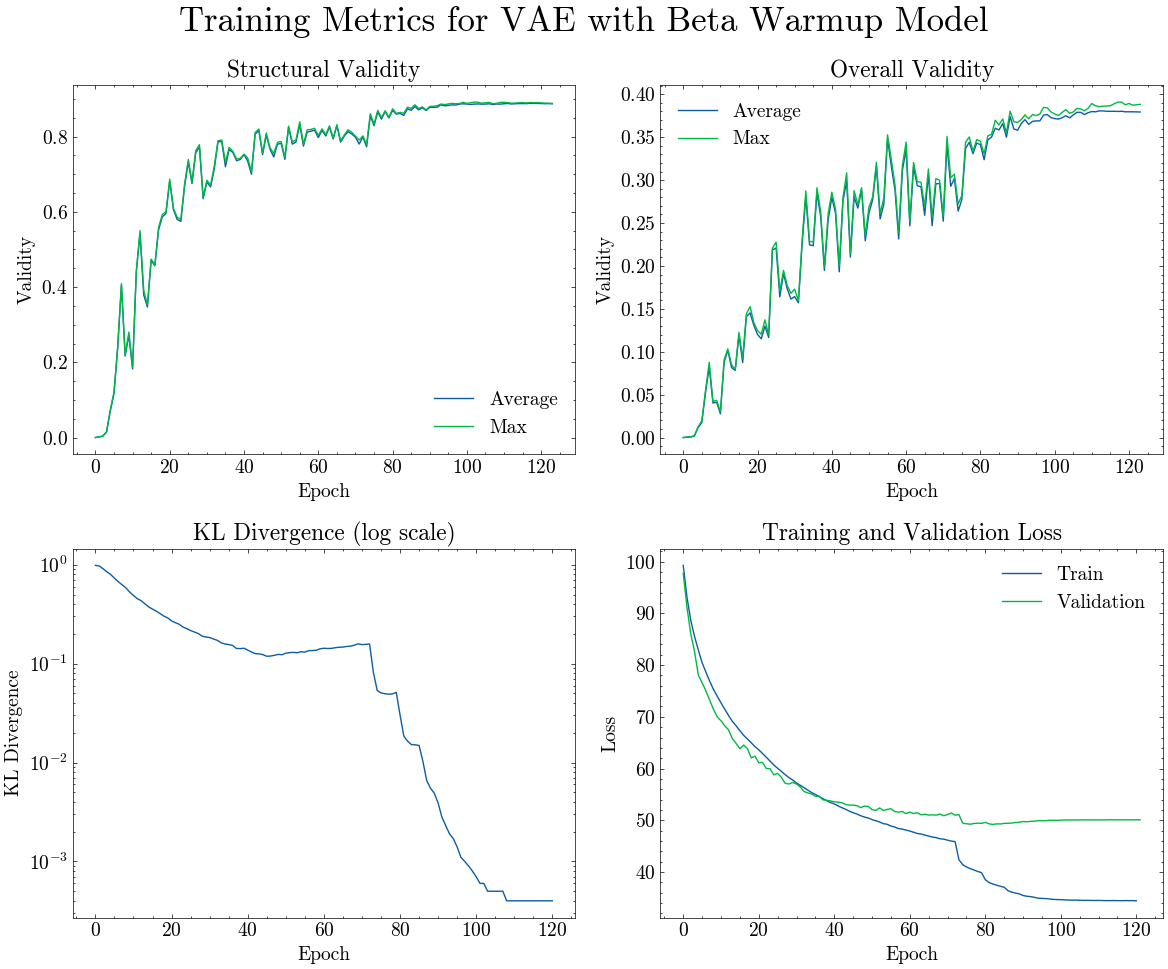

In [21]:
import re
import matplotlib.pyplot as plt
import numpy as np

logv2 = "Liu_Kheyer_Retrosynthesis_Data/reproduced/v4.3/train.log"
logv2_str = open(logv2, "r").read()

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

# Structural Validity
patt = re.compile(r"- Validity\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})")
vals = patt.findall(logv2_str)
avg_vals = [float(val[0]) for val in vals]
max_vals = [float(val[3]) for val in vals]
std_vals = [float(val[1]) for val in vals]
axs[0].plot(avg_vals, label="Average")
axs[0].plot(max_vals, label="Max")
axs[0].set_title("Structural Validity")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Validity")
axs[0].legend()
print("Avg Structural Validity", np.max(avg_vals), np.argmax(avg_vals),
      "Maximum:", max_vals[np.argmax(avg_vals)],
      "Std:", std_vals[np.argmax(avg_vals)])
print("Max Structural Validity", np.max(max_vals), np.argmax(max_vals),
      "Average:", avg_vals[np.argmax(max_vals)],
      "Std:", std_vals[np.argmax(max_vals)])

# Overall Validity
patt = re.compile(r"- Overall Validity\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})\s+(0\.\d{4})")
vals = patt.findall(logv2_str)
avg_vals = [float(val[0]) for val in vals]
max_vals = [float(val[3]) for val in vals]
std_vals = [float(val[1]) for val in vals]
axs[1].plot(avg_vals, label="Average")
axs[1].plot(max_vals, label="Max")
axs[1].set_title("Overall Validity")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Validity")
axs[1].legend()
print("Avg Overall Validity", np.max(avg_vals), np.argmax(avg_vals),
      "Maximum:", max_vals[np.argmax(avg_vals)],
      "Std:", std_vals[np.argmax(avg_vals)])
print("Max Overall Validity", np.max(max_vals), np.argmax(max_vals),
      "Average:", avg_vals[np.argmax(max_vals)],
      "Std:", std_vals[np.argmax(max_vals)])

# KL Divergence
patt = re.compile(r"epoch: \d+, avg_loss: \d{2}\.\d{4}, kl: (\d\.\d{4})")
vals = [float(val) for val in patt.findall(logv2_str)]
axs[2].plot(vals)
axs[2].set_title("KL Divergence (log scale)")
axs[2].set_xlabel("Epoch")
axs[2].set_ylabel("KL Divergence")
axs[2].set_yscale("log")

# Train/Validation Loss
patt_train = re.compile(r"epoch: \d+, avg_loss: (\d{2}\.\d{4})")
train_vals = [float(val) for val in patt_train.findall(logv2_str)]
patt_val = re.compile(r"VAL --- avg_loss: (\d{2}\.\d{4})")
valid_vals = [float(val) for val in patt_val.findall(logv2_str)]
axs[3].plot(train_vals, label="Train")
axs[3].plot(valid_vals, label="Validation")
axs[3].set_title("Training and Validation Loss")
axs[3].set_xlabel("Epoch")
axs[3].set_ylabel("Loss")
axs[3].legend()
print("Min Validation Loss at Epoch", np.argmin(valid_vals),
      "Min Loss:", np.min(valid_vals),
      "Final Val Loss:", valid_vals[-1])
fig.suptitle("Training Metrics for VAE with Beta Warmup Model", fontsize=25)
plt.tight_layout()
plt.savefig("results/vae_with_beta_warmup_model_evaluation_metrics.png", dpi=300)
plt.show()

## Generate Chemical Reactions From Each Models

In [5]:
def generate_and_evaluate(generator, evaluator, generated_path, seeds=[42, 0, 250, 1000, 350],logging=None):
    # Initialize metrics dictionary
    metrics = {
        "JSS": [],
        "Similarity": [],
        "String Similarity": [],
        "Validity": [],
        "Novelty Percentage": [],
        "Unique Percentage": [],
        "Average Inter Dissimilarity": [],
        "Overall Validity": [],
        "Normalized Vendi Score": [],
        "Normalized Vendi Score (q=0.1)": [],
        "Normalized Vendi Score (q=inf)": [],
        "Avg Normalized Vendi Score Per Class": [],
        "Filter 1": [],
        "Filter 2": [],
        "Filter 3": [],
        "Filter 4": [],
    }


    for seed in seeds:
        generator.generate_samples(seed=seed)
        evaluator.generate_metrics_evaluation(generated_path)
        metrics["JSS"].append(evaluator.results["jss"])
        metrics["Similarity"].append(evaluator.results["avg_similarity"])
        metrics["String Similarity"].append(evaluator.results["avg_str_similarity"])
        metrics["Validity"].append(evaluator.results["valid"])
        metrics["Novelty Percentage"].append(evaluator.results["novelty_perc"])
        metrics["Unique Percentage"].append(evaluator.results["unique_perc"])
        metrics["Average Inter Dissimilarity"].append(
            evaluator.results["average_inter_dissimilarity"]
        )
        metrics["Overall Validity"].append(evaluator.results["validated"])
        metrics["Normalized Vendi Score"].append(evaluator.results["vendi_score_k"])
        metrics["Normalized Vendi Score (q=0.1)"].append(
            evaluator.results["vendi_score_k_small"]
        )
        metrics["Normalized Vendi Score (q=inf)"].append(
            evaluator.results["vendi_score_k_inf"]
        )
        metrics["Avg Normalized Vendi Score Per Class"].append(
            evaluator.results["avg_vs_score_per_class"]
        )
        metrics["Filter 1"].append(evaluator.results["filter1"])
        metrics["Filter 2"].append(evaluator.results["filter2"])
        metrics["Filter 3"].append(evaluator.results["filter3"])
        metrics["Filter 4"].append(evaluator.results["filter4"])

        if logging:
            logging.info(f"""Seed {seed}: JSS={evaluator.results["jss"]:.4f}, Sim={evaluator.results["avg_similarity"]:.4f}, StrSim={evaluator.results["avg_str_similarity"]:.4f}, Val={evaluator.results["valid"]:.4f}, NoveltyPerc={evaluator.results["novelty_perc"]:.4f}, 
            UniquePerc={evaluator.results["unique_perc"]:.4f}, IntDiv={evaluator.results["average_inter_dissimilarity"]:.4f}, OverallVal={evaluator.results["validated"]:.4f}, 
            NVS={evaluator.results["vendi_score_k"]:.4f}, NVS(q=0.1)={evaluator.results["vendi_score_k_small"]:.4f}, NVS(q=inf)={evaluator.results["vendi_score_k_inf"]:.4f}, AvgNVSPerClass={evaluator.results["avg_vs_score_per_class"]:.4f}""")

        else:
            print(f"""Seed {seed}: JSS={evaluator.results["jss"]:.4f}, Sim={evaluator.results["avg_similarity"]:.4f}, StrSim={evaluator.results["avg_str_similarity"]:.4f}, Val={evaluator.results["valid"]:.4f}, NoveltyPerc={evaluator.results["novelty_perc"]:.4f}, 
            UniquePerc={evaluator.results["unique_perc"]:.4f}, IntDiv={evaluator.results["average_inter_dissimilarity"]:.4f}, OverallVal={evaluator.results["validated"]:.4f}, 
            NVS={evaluator.results["vendi_score_k"]:.4f}, NVS(q=0.1)={evaluator.results["vendi_score_k_small"]:.4f}, NVS(q=inf)={evaluator.results["vendi_score_k_inf"]:.4f}, AvgNVSPerClass={evaluator.results["avg_vs_score_per_class"]:.4f}""")

    # Print summary statistics
    if logging:
        logging.info("\nSummary Statistics:")
        logging.info(f"{'Metric':<25} {'Avg':<8} {'Std':<8} {'Min':<8} {'Max':<8}")
    else:
        print("\nSummary Statistics:")
        print(f"{'Metric':<25} {'Avg':<8} {'Std':<8} {'Min':<8} {'Max':<8}")
    for metric, values in metrics.items():
        if logging:
            logging.info(
                f"{metric:<25} {np.mean(values):<8.4f} {np.std(values):<8.4f} {np.min(values):<8.4f} {np.max(values):<8.4f}"
            )
        else:   
            print(
            f"{metric:<25} {np.mean(values):<8.4f} {np.std(values):<8.4f} {np.min(values):<8.4f} {np.max(values):<8.4f}"
        )

In [ ]:
import os
import json
import numpy as np
import torch
import random
from eval import Evaluator
from generate import LSTMLMGenerator, VAEGenerator
import logging

configs = {"LSTM 1 layer": "configs/LSTM_1layer_best_config.json",
    "LSTM 2 layers": "configs/LSTM_2layers_best_config.json",
    "LSTM 3 layers": "configs/LSTM_3layers_best_config.json",
    "LSTM 4 layers": "configs/LSTM_4layers_best_config.json",   
    "VAE vanilla": "configs/VAE_vanilla_best_config.json",
    "VAE with warmup":"configs/VAE_aggressive_best_config.json"}
logging.basicConfig(level=logging.INFO,
                    format='',
                    handlers=[logging.FileHandler("results/results.log"),
                              logging.StreamHandler()])

for model,config_path in configs.items():
    with open(config_path, "r", encoding="utf-8") as file:
        config = json.load(file)
        config = {
            param: value for _, params in config.items() for param, value in params.items()
        }
    config["cuda"] = config["cuda"] and torch.cuda.is_available()
    torch.manual_seed(config["seed"])
    torch.use_deterministic_algorithms(True)
    np.random.seed(config["seed"])
    random.seed(config["seed"])
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
    if config["cuda"]:
        torch.cuda.manual_seed(config["seed"])
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True

    if config["model"] == "LSTM":
        print("generating with LSTM")
        generator = LSTMLMGenerator(config=config)
    elif config["model"] == "VAE":
        print("generating with VAE")
        generator = VAEGenerator(config=config)
    evaluator = Evaluator(config)
    logging.info(f"Evaluating {model}...")
    generate_and_evaluate(generator, evaluator, config["gene_path"],seeds=[42],logging=logging)

generating with LSTM


sentencepiece_trainer.cc(178) LOG(INFO) /home/anis/miniconda3/envs/chemgen_env/lib/python3.9/site-packages/torch/nn/modules/rnn.py:62: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "
Running command: --input=Liu_Kheyer_Retrosynthesis_Data/vocab2.txt --model_prefix=m  --user_defined_symbols=[BOS],[EOS],[PAD],. --vocab_size=56 --bos_id=-1 --eos_id=-1
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: Liu_Kheyer_Retrosynthesis_Data/vocab2.txt
  input_format: 
  model_prefix: m
  model_type: UNIGRAM
  vocab_size: 56
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_

generating with LSTM


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=Liu_Kheyer_Retrosynthesis_Data/vocab2.txt --model_prefix=m  --user_defined_symbols=[BOS],[EOS],[PAD],. --vocab_size=56 --bos_id=-1 --eos_id=-1
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: Liu_Kheyer_Retrosynthesis_Data/vocab2.txt
  input_format: 
  model_prefix: m
  model_type: UNIGRAM
  vocab_size: 56
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: [BOS]
  user_defined_symbols: [EOS]
  user_defined_symbols: [PAD]
  user_defined_symbols: .
  required_cha

generating with LSTM


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=Liu_Kheyer_Retrosynthesis_Data/vocab2.txt --model_prefix=m  --user_defined_symbols=[BOS],[EOS],[PAD],. --vocab_size=56 --bos_id=-1 --eos_id=-1
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: Liu_Kheyer_Retrosynthesis_Data/vocab2.txt
  input_format: 
  model_prefix: m
  model_type: UNIGRAM
  vocab_size: 56
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: [BOS]
  user_defined_symbols: [EOS]
  user_defined_symbols: [PAD]
  user_defined_symbols: .
  required_cha

generating with LSTM


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=Liu_Kheyer_Retrosynthesis_Data/vocab2.txt --model_prefix=m  --user_defined_symbols=[BOS],[EOS],[PAD],. --vocab_size=56 --bos_id=-1 --eos_id=-1
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: Liu_Kheyer_Retrosynthesis_Data/vocab2.txt
  input_format: 
  model_prefix: m
  model_type: UNIGRAM
  vocab_size: 56
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: [BOS]
  user_defined_symbols: [EOS]
  user_defined_symbols: [PAD]
  user_defined_symbols: .
  required_cha

generating with VAE


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=Liu_Kheyer_Retrosynthesis_Data/vocab2.txt --model_prefix=m  --user_defined_symbols=[BOS],[EOS],[PAD],. --vocab_size=56 --bos_id=-1 --eos_id=-1
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: Liu_Kheyer_Retrosynthesis_Data/vocab2.txt
  input_format: 
  model_prefix: m
  model_type: UNIGRAM
  vocab_size: 56
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: [BOS]
  user_defined_symbols: [EOS]
  user_defined_symbols: [PAD]
  user_defined_symbols: .
  required_cha

### Sampling and Saving Reactions to Disk

In [43]:
from rdkit import Chem
from rdkit.Chem import Draw, rdChemReactions, AllChem
from rdkit.Chem.Draw import rdMolDraw2D
import os
import cairosvg

def draw_and_save_reactions(reaction_smarts_list, output_prefix="reaction"):
    svg_dir = "results/reactions/svg"
    png_dir = "results/reactions/png"
    os.makedirs(svg_dir, exist_ok=True)
    os.makedirs(png_dir, exist_ok=True)

    for i, rxn_smarts in enumerate(reaction_smarts_list):
        rxn = rdChemReactions.ReactionFromSmarts(rxn_smarts, useSmiles=True)
        if rxn is None:
            print(f"Invalid reaction SMARTS: {rxn_smarts}")
            continue

        # Rebuild the reaction using clean mol blocks
        #new_rxn = AllChem.ChemicalReaction()
        #for mol in rxn.GetReactants():
        #    mol = Chem.MolFromMolBlock(Chem.MolToMolBlock(mol))
        #    new_rxn.AddReactantTemplate(mol)
        #for mol in rxn.GetProducts():
        #    mol = Chem.MolFromMolBlock(Chem.MolToMolBlock(mol))
        #    new_rxn.AddProductTemplate(mol)

        # Configure drawer for large, legible output
        width, height = 3000, 1000
        drawer = rdMolDraw2D.MolDraw2DSVG(width, height)
        dopts = drawer.drawOptions()

        dopts.prepareMolsBeforeDrawing = True
        dopts.fixedBondLength = 65
        dopts.bondLineWidth = 3.0
        dopts.fontSize = 36
        dopts.minFontSize = 28
        dopts.padding = 0.1
        dopts.useBWAtomPalette()
        dopts.includeAtomNumbers = False
        dopts.includeChiralFlag = False
        dopts.includeStereoAnnotation = False

        # Draw the reaction
        drawer.DrawReaction(rxn)
        drawer.FinishDrawing()
        svg_data = drawer.GetDrawingText().encode('utf-8')

        # Save SVG
        svg_path = os.path.join(svg_dir, f"{output_prefix}_{i+1}.svg")
        with open(svg_path, "wb") as f:
            f.write(svg_data)

        # Convert SVG to high-resolution PNG
        png_path = os.path.join(png_dir, f"{output_prefix}_{i+1}.png")
        cairosvg.svg2png(url=svg_path, write_to=png_path, dpi=1500)
        print(f"Saved: {svg_path}, {png_path}")

In [2]:
import json
import os

def create_smiles_json(smiles_list, output_file):
    """
    Writes a dictionary to JSON where each key is a reaction name based on the filename,
    and each value is the corresponding SMILES or reaction string.

    Example:
    {
        "reference_00000": "CCO>>CC=O",
        "reference_00001": "CCN>>CC=NH",
        ...
    }

    Parameters:
    - smiles_list (list of str): List of SMILES or reaction strings.
    - output_file (str): Path to the output JSON file.
    """
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    base_name = os.path.splitext(os.path.basename(output_file))[0]

    data = {f"{base_name}_{i+1}": s for i, s in enumerate(smiles_list)}

    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)

    print(f"Wrote {len(smiles_list)} reactions to {output_file}")

In [3]:
import matplotlib.pyplot as plt

%matplotlib inline
import os
import numpy as np
import sentencepiece as spm
import scienceplots
import pandas as pd
from rdkit import Chem
import torch, random

plt.rcParams.update({"text.usetex": True, "font.size": 14})
plt.style.use(["science", "no-latex"])

seed = 1000
torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)
np.random.seed(seed)
random.seed(seed)

# sample 10 reactions from the reference dataset based on reaction_type
reference_df = pd.read_csv("train_ref_dataset.csv")
reference_df_sampled = reference_df.groupby("reaction_type").apply(lambda x: x.sample(1, random_state=seed))[["full_input_format"]]
draw_and_save_reactions(reference_df_sampled["full_input_format"].tolist(), output_prefix="reference")
# Create JSON file with the sampled reactions
create_smiles_json(reference_df_sampled["full_input_format"].tolist(), output_file="results/reactions/reference.json")

Saved: results/reactions/svg/reference_1.svg, results/reactions/png/reference_1.png
Saved: results/reactions/svg/reference_2.svg, results/reactions/png/reference_2.png
Saved: results/reactions/svg/reference_3.svg, results/reactions/png/reference_3.png
Saved: results/reactions/svg/reference_4.svg, results/reactions/png/reference_4.png
Saved: results/reactions/svg/reference_5.svg, results/reactions/png/reference_5.png
Saved: results/reactions/svg/reference_6.svg, results/reactions/png/reference_6.png
Saved: results/reactions/svg/reference_7.svg, results/reactions/png/reference_7.png
Saved: results/reactions/svg/reference_8.svg, results/reactions/png/reference_8.png
Saved: results/reactions/svg/reference_9.svg, results/reactions/png/reference_9.png
Saved: results/reactions/svg/reference_10.svg, results/reactions/png/reference_10.png
Wrote 10 reactions to results/reactions/reference.json


In [8]:
import os
import json
import numpy as np
import torch
import random
from eval import Evaluator
configs = {
    "LSTM 3 layers": "configs/LSTM_3layers_best_config.json",
    "VAE vanilla": "configs/VAE_vanilla_best_config.json",
    "VAE with warmup":"configs/VAE_aggressive_best_config.json"}
for model,config_path in configs.items():
    with open(config_path, "r", encoding="utf-8") as file:
        config = json.load(file)
        config = {
            param: value for _, params in config.items() for param, value in params.items()
        }
    config["cuda"] = config["cuda"] and torch.cuda.is_available()
    torch.manual_seed(config["seed"])
    torch.use_deterministic_algorithms(True)
    np.random.seed(config["seed"])
    random.seed(config["seed"])
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
    if config["cuda"]:
        torch.cuda.manual_seed(config["seed"])
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True
    evaluator = Evaluator(config)
    evaluator.generate_metrics_evaluation(config["gene_path"])
    valid_df =evaluator.valid_df
    valid_df["reaction_type"] = evaluator.rxn_pred
    sampled = valid_df.groupby("reaction_type").apply(lambda x: x.sample(1, random_state=seed))
    draw_and_save_reactions(sampled["decoded_smiles"].tolist(), output_prefix=model.replace(" ", "_").lower())
    create_smiles_json(sampled["decoded_smiles"].tolist(), output_file=f"results/reactions/{model.replace(' ', '_').lower()}.json")

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=Liu_Kheyer_Retrosynthesis_Data/vocab2.txt --model_prefix=m  --user_defined_symbols=[BOS],[EOS],[PAD],. --vocab_size=56 --bos_id=-1 --eos_id=-1
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: Liu_Kheyer_Retrosynthesis_Data/vocab2.txt
  input_format: 
  model_prefix: m
  model_type: UNIGRAM
  vocab_size: 56
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: [BOS]
  user_defined_symbols: [EOS]
  user_defined_symbols: [PAD]
  user_defined_symbols: .
  required_cha

Saved: results/reactions/svg/lstm_3_layers_1.svg, results/reactions/png/lstm_3_layers_1.png
Saved: results/reactions/svg/lstm_3_layers_2.svg, results/reactions/png/lstm_3_layers_2.png
Saved: results/reactions/svg/lstm_3_layers_3.svg, results/reactions/png/lstm_3_layers_3.png
Saved: results/reactions/svg/lstm_3_layers_4.svg, results/reactions/png/lstm_3_layers_4.png
Saved: results/reactions/svg/lstm_3_layers_5.svg, results/reactions/png/lstm_3_layers_5.png
Saved: results/reactions/svg/lstm_3_layers_6.svg, results/reactions/png/lstm_3_layers_6.png
Saved: results/reactions/svg/lstm_3_layers_7.svg, results/reactions/png/lstm_3_layers_7.png
Saved: results/reactions/svg/lstm_3_layers_8.svg, results/reactions/png/lstm_3_layers_8.png
Saved: results/reactions/svg/lstm_3_layers_9.svg, results/reactions/png/lstm_3_layers_9.png
Saved: results/reactions/svg/lstm_3_layers_10.svg, results/reactions/png/lstm_3_layers_10.png
Wrote 10 reactions to results/reactions/lstm_3_layers.json


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=Liu_Kheyer_Retrosynthesis_Data/vocab2.txt --model_prefix=m  --user_defined_symbols=[BOS],[EOS],[PAD],. --vocab_size=56 --bos_id=-1 --eos_id=-1
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: Liu_Kheyer_Retrosynthesis_Data/vocab2.txt
  input_format: 
  model_prefix: m
  model_type: UNIGRAM
  vocab_size: 56
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: [BOS]
  user_defined_symbols: [EOS]
  user_defined_symbols: [PAD]
  user_defined_symbols: .
  required_cha

Saved: results/reactions/svg/vae_vanilla_1.svg, results/reactions/png/vae_vanilla_1.png
Saved: results/reactions/svg/vae_vanilla_2.svg, results/reactions/png/vae_vanilla_2.png
Saved: results/reactions/svg/vae_vanilla_3.svg, results/reactions/png/vae_vanilla_3.png
Saved: results/reactions/svg/vae_vanilla_4.svg, results/reactions/png/vae_vanilla_4.png
Saved: results/reactions/svg/vae_vanilla_5.svg, results/reactions/png/vae_vanilla_5.png
Saved: results/reactions/svg/vae_vanilla_6.svg, results/reactions/png/vae_vanilla_6.png
Saved: results/reactions/svg/vae_vanilla_7.svg, results/reactions/png/vae_vanilla_7.png
Saved: results/reactions/svg/vae_vanilla_8.svg, results/reactions/png/vae_vanilla_8.png
Saved: results/reactions/svg/vae_vanilla_9.svg, results/reactions/png/vae_vanilla_9.png
Saved: results/reactions/svg/vae_vanilla_10.svg, results/reactions/png/vae_vanilla_10.png
Wrote 10 reactions to results/reactions/vae_vanilla.json


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=Liu_Kheyer_Retrosynthesis_Data/vocab2.txt --model_prefix=m  --user_defined_symbols=[BOS],[EOS],[PAD],. --vocab_size=56 --bos_id=-1 --eos_id=-1
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: Liu_Kheyer_Retrosynthesis_Data/vocab2.txt
  input_format: 
  model_prefix: m
  model_type: UNIGRAM
  vocab_size: 56
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: [BOS]
  user_defined_symbols: [EOS]
  user_defined_symbols: [PAD]
  user_defined_symbols: .
  required_cha

Saved: results/reactions/svg/vae_with_warmup_1.svg, results/reactions/png/vae_with_warmup_1.png
Saved: results/reactions/svg/vae_with_warmup_2.svg, results/reactions/png/vae_with_warmup_2.png
Saved: results/reactions/svg/vae_with_warmup_3.svg, results/reactions/png/vae_with_warmup_3.png
Saved: results/reactions/svg/vae_with_warmup_4.svg, results/reactions/png/vae_with_warmup_4.png
Saved: results/reactions/svg/vae_with_warmup_5.svg, results/reactions/png/vae_with_warmup_5.png
Saved: results/reactions/svg/vae_with_warmup_6.svg, results/reactions/png/vae_with_warmup_6.png
Saved: results/reactions/svg/vae_with_warmup_7.svg, results/reactions/png/vae_with_warmup_7.png
Saved: results/reactions/svg/vae_with_warmup_8.svg, results/reactions/png/vae_with_warmup_8.png
Saved: results/reactions/svg/vae_with_warmup_9.svg, results/reactions/png/vae_with_warmup_9.png
Saved: results/reactions/svg/vae_with_warmup_10.svg, results/reactions/png/vae_with_warmup_10.png
Wrote 10 reactions to results/reaction

In [9]:
import os
import json

reactions_smiles = [
    "results/reactions/reference.json",
    "results/reactions/lstm_3_layers.json",
    "results/reactions/vae_vanilla.json",
    "results/reactions/vae_with_warmup.json",
]

combined_reactions = {}

for file_path in reactions_smiles:
    with open(file_path, "r") as f:
        data = json.load(f)
    
    prefix = os.path.splitext(os.path.basename(file_path))[0]
    
    # Rename keys with prefix
    for key, value in data.items():
        combined_reactions[key] = value

# Save combined dictionary
with open("results/reactions/combined_reactions.json", "w") as f:
    json.dump(combined_reactions, f, indent=2)
#shuffle the keys in the combined_reactions dictionary
keys = list(combined_reactions.keys())
random.shuffle(keys)
shuffled_combined_reactions = {key: combined_reactions[key] for key in keys}
with open("results/reactions/shuffled_combined_reactions.json", "w") as f:
    json.dump(shuffled_combined_reactions, f, indent=2)

In [3]:
configs = {"LSTM 1 layer": "configs/LSTM_1layer_best_config.json",
    "LSTM 2 layers": "configs/LSTM_2layers_best_config.json",
    "LSTM 3 layers": "configs/LSTM_3layers_best_config.json",
    "LSTM 4 layers": "configs/LSTM_4layers_best_config.json",   
    "VAE vanilla": "configs/VAE_vanilla_best_config.json",
    "VAE with warmup":"configs/VAE_aggressive_best_config.json"}

In [ ]:
import os
import json
import numpy as np
import torch
import random
from eval import Evaluator
from generate import LSTMLMGenerator, VAEGenerator
import logging
logging.basicConfig(level=logging.INFO,
                    format='',
                    handlers=[logging.FileHandler("results/all_results.log"),
                              logging.StreamHandler()])

for model,config_path in configs.items():
    with open(config_path, "r", encoding="utf-8") as file:
        config = json.load(file)
        config = {
            param: value for _, params in config.items() for param, value in params.items()
        }
    config["cuda"] = config["cuda"] and torch.cuda.is_available()
    torch.manual_seed(config["seed"])
    torch.use_deterministic_algorithms(True)
    np.random.seed(config["seed"])
    random.seed(config["seed"])
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
    if config["cuda"]:
        torch.cuda.manual_seed(config["seed"])
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True

    if config["model"] == "LSTM":
        print("generating with LSTM")
        generator = LSTMLMGenerator(config=config)
    elif config["model"] == "VAE":
        print("generating with VAE")
        generator = VAEGenerator(config=config)
    evaluator = Evaluator(config)
    logging.info(f"Evaluating {model}...")
    generate_and_evaluate(generator, evaluator, config["gene_path"],logging=logging)

generating with LSTM


sentencepiece_trainer.cc(178) /home/anis/miniconda3/envs/chemgen_env/lib/python3.9/site-packages/torch/nn/modules/rnn.py:62: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "
LOG(INFO) Running command: --input=Liu_Kheyer_Retrosynthesis_Data/vocab2.txt --model_prefix=m  --user_defined_symbols=[BOS],[EOS],[PAD],. --vocab_size=56 --bos_id=-1 --eos_id=-1
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: Liu_Kheyer_Retrosynthesis_Data/vocab2.txt
  input_format: 
  model_prefix: m
  model_type: UNIGRAM
  vocab_size: 56
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_

In [56]:
draw_and_save_reactions(reaction_smarts_list=
["O=Cc1ccc(-c2nc3ccccc3o2)cc1>>OCc1ccc(-c2nc3ccccc3o2)cc1","N#Cc1ccc(C2=NOC(c3cc(Cl)cc(Cl)c3)(C(F)(F)F)C2)cc1Cl>>N#Cc1ccc(C2=NOC(c3cc(Cl)cc(Cl)c3)(C(F)(F)F)C2)cc1F"
], output_prefix="paper_original_reaction_vae_with_warmup")
draw_and_save_reactions(reaction_smarts_list=
["O=Cc1ccc(c(n2)oc3c2cccc3)cc1.[H][H]>>OCc4ccc(c(n5)oc6c5cccc6)cc4","N#Cc1c(Cl)cc(C2=NOC(C(F)(F)F)(C2)c3cc(Cl)cc(Cl)c3)cc1.[Na]F>>N#Cc4c(F)cc(C5=NOC(C(F)(F)F)(C5)c6cc(Cl)cc(Cl)c6)cc4.[Na]Cl"
], output_prefix="paper_modified_reaction_vae_with_warmup")
draw_and_save_reactions(reaction_smarts_list=
["COC(=O)c1ccc(C)cn1.O=C1CCC(=O)N1Br>>COC(=O)c1ccc(CBr)cn1","CC(C)(C)OC(=O)OC(=O)OC(C)(C)C.N#Cc1ccc2c(c1)CCN2>>CC(C)(C)OC(=O)N1CCc2ccc([N+](=O)[O-])cc2C1"
], output_prefix="paper_original_reaction_vae_vanilla")
draw_and_save_reactions(reaction_smarts_list=
["COC(c1ncc(C)cc1)=O.O=C2CCC(N2Br)=O>>COC(c3ncc(CBr)cc3)=O.O=C4CCC(N4[H])=O","N#Cc1cc(CCN2)c2cc1.CC(C)(OC(OC(OC(C)(C)C)=O)=O)C.[H]OO[H]>>CC(C)(OC(N3CCc4c(C3)cc([N+]([O-])=O)cc4)=O)C.[H]OC(OC(C)(C)C)=O"
], output_prefix="paper_modified_reaction_vae_vanilla")
draw_and_save_reactions(reaction_smarts_list=
["CNOC.O=C(OC(=O)C(F)(F)F)C(F)(F)F>>CON(C)C(=O)C(F)(F)F","CC(C)(C)OC(=O)CBr.N#Cc1cc(F)cc(N)c1>>CC(C)(C)OC(=O)CNc1cc(F)cc(C#N)c1"
], output_prefix="paper_original_reaction_lstm_4_layers")
draw_and_save_reactions(reaction_smarts_list=
["[H]N(C)OC.O=C(C(F)(F)F)OC(C(F)(F)F)=O>>CON(C(C(F)(F)F)=O)C.OC(C(F)(F)F)=O","N#Cc1cc(N)cc(F)c1.CC(C)(OC(CBr)=O)C>>CC(C)(OC(CNc2cc(C#N)cc(F)c2)=O)C.Br[H]"
], output_prefix="paper_modified_reaction_lstm_4_layers")

Saved: results/reactions/svg/paper_original_reaction_vae_with_warmup_1.svg, results/reactions/png/paper_original_reaction_vae_with_warmup_1.png
Saved: results/reactions/svg/paper_original_reaction_vae_with_warmup_2.svg, results/reactions/png/paper_original_reaction_vae_with_warmup_2.png
Saved: results/reactions/svg/paper_modified_reaction_vae_with_warmup_1.svg, results/reactions/png/paper_modified_reaction_vae_with_warmup_1.png
Saved: results/reactions/svg/paper_modified_reaction_vae_with_warmup_2.svg, results/reactions/png/paper_modified_reaction_vae_with_warmup_2.png
Saved: results/reactions/svg/paper_original_reaction_vae_vanilla_1.svg, results/reactions/png/paper_original_reaction_vae_vanilla_1.png
Saved: results/reactions/svg/paper_original_reaction_vae_vanilla_2.svg, results/reactions/png/paper_original_reaction_vae_vanilla_2.png
Saved: results/reactions/svg/paper_modified_reaction_vae_vanilla_1.svg, results/reactions/png/paper_modified_reaction_vae_vanilla_1.png
Saved: results/r